# Modelo Multimodal CNN-LSTM

Este cuaderno implementa el entrenamiento y evaluación del modelo **Multimodal CNN-LSTM** para la estimación de rastros térmicos.

A diferencia del modelo `CNN-LSTM` base (que procesa únicamente las secuencias de imágenes térmicas), esta versión multimodal integra:
1. **Características espacio-temporales** extraídas de la secuencia de imágenes mediante un extractor Lite-DSTFS y una celda LSTM.
2. **Variables contextuales tabulares** (8 variables ambientales continuas normalizadas y 2 variables categóricas binarias que codifican el tipo de superficie).

Ambas ramas se fusionan mediante una **Fusión Tardía (Late Fusion)** antes de entrar a la cabeza de regresión final.

El cargador de datos [MultimodalSequenceDataset](file:///D:/ulima/Ulima_archivos/UL-2026-1/Seminario1/experimentacion/flir_test/src/loaders/multimodal_sequence_loader.py) y el modelo [MultimodalThermalCNNLSTM](file:///D:/ulima/Ulima_archivos/UL-2026-1/Seminario1/experimentacion/flir_test/src/models/multimodal_cnn_lstm.py) están estructurados como módulos dentro del proyecto en las carpetas `src/loaders/` y `src/models/` respectivamente.

In [1]:
import sys
import random
from pathlib import Path

# Añadir el directorio raíz al path de Python para permitir importaciones correctas
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from src.loaders import MultimodalSequenceDataset
from src.models import MultimodalThermalCNNLSTM
from src.utils import (
    SqrtScaledMSELoss,
    build_subject_split_plan,
    sequence_ids_for_subjects,
    subject_summary,
    plot_learning_curves,
    plot_prediction_calibration,
    plot_error_by_time_window
)

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

### 1. Configuración de Parámetros Generales

In [2]:
dev = "cuda" if torch.cuda.is_available() else "cpu"

CONFIG = {
    "device": dev,
    "min_time_s": 0.0,
    "time_scale": 30.0,
    "seq_len": 5,
    "min_delta": 1.0,
    "patience": 15
}

metadata_path = "../processed_data/metadata_train.csv"
print(f"Dispositivo de cómputo configurado: {dev}")

Dispositivo de cómputo configurado: cuda


### 2. Configuración del Plan de Partición Híbrido (Opción C)

In [3]:
# Cargar datos completos para inspección y armado de folds
df_full = pd.read_csv(metadata_path)
print("Resumen de sujetos en metadata:")
print(subject_summary(df_full))

# Construir el split reservando a 'tania' y 'matias' en Test (y a los incompletos como 'eduardo')
plan = build_subject_split_plan(
    df_full,
    n_splits=9,
    seed=42,
    test_subjects=["tania", "matias"],
    reserve_incomplete_for_test=True
)

print("\n=== ESTRUCTURA DEL PLAN HÍBRIDO ===")
print(f"Sujetos de Test Fijo ({plan.num_test_subjects}): {plan.test_subjects} ({plan.num_test_samples} muestras)")
print(f"Sujetos para Train-Val ({plan.num_trainval_subjects}): {plan.trainval_subjects} ({plan.num_trainval_samples} muestras)")
print(f"Folds de validación cruzada interna: {len(plan.folds)}")

Resumen de sujetos en metadata:
         name  n_sequences  n_samples      surface  gender  is_complete
0      alonso            6        282  glass, wood    male         True
1      angelo            6        281  glass, wood    male         True
2     claudia            6        282  glass, wood  female         True
3     eduardo            1         47         wood    male        False
4     esteban            6        276  glass, wood    male         True
5    fabricio            6        277  glass, wood    male         True
6   juandiego            6        355  glass, wood    male         True
7      matias            6        282  glass, wood    male         True
8     melissa            6        282  glass, wood  female         True
9      renato            6        278  glass, wood    male         True
10      tania            6        278  glass, wood  female         True
11    yohamin            6        276  glass, wood    male         True

=== ESTRUCTURA DEL PLAN HÍBRIDO

### 3. Función de Evaluación Multimodal Personalizada

In [4]:
def eval_multimodal_cnn_lstm_metrics(model: torch.nn.Module, loader: DataLoader, device: str) -> dict[str, float]:
    """
    Calcula las métricas desempacando la secuencia visual y las variables tabulares.
    """
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for x_seq, x_tab, y in loader:
            x_seq, x_tab, y = x_seq.to(device), x_tab.to(device), y.to(device)
            p = model(x_seq, x_tab)
            all_preds.append(p.cpu())
            all_targets.append(y.cpu())
            
    from src.utils.metrics import _compute_metrics
    return _compute_metrics(torch.cat(all_preds, dim=0), torch.cat(all_targets, dim=0))

### 4. Fase A: Validación Cruzada de 5 Folds (Modelo Baseline)

In [5]:
BASELINE_CONFIG = {
    "epochs": 120,
    "patience": 15,
    "min_delta": 1.0,
    "batch_size": 8,
    "lr": 0.0003,
    "weight_decay": 0.001,
    "lstm_hidden_dim": 128,
    "dropout": 0.2
}

set_seed(42)
fold_metrics_base = []
histories_base = []

print("=" * 60)
print("VALIDACIÓN CRUZADA MULTIMODAL CNN-LSTM (5 FOLDS) - BASELINE")
print("=" * 60)

for fold in plan.folds:
    print(f"\nEntrenando Fold {fold.fold}/{len(plan.folds)} <<<")
    print(f"Train subjects: {fold.train_subjects}")
    print(f"Val subjects: {fold.val_subjects}")
    
    train_seq_ids = sequence_ids_for_subjects(df_full, fold.train_subjects)
    val_seq_ids = sequence_ids_for_subjects(df_full, fold.val_subjects)
    
    # Datasets con normalización aislada por fold
    train_ds = MultimodalSequenceDataset(
        metadata_csv=metadata_path,
        is_train=True,
        min_time_s=CONFIG["min_time_s"],
        seq_len=CONFIG["seq_len"],
        sequence_ids=train_seq_ids
    )
    val_ds = MultimodalSequenceDataset(
        metadata_csv=metadata_path,
        is_train=False,
        min_time_s=CONFIG["min_time_s"],
        seq_len=CONFIG["seq_len"],
        sequence_ids=val_seq_ids,
        means=train_ds.means,
        stds=train_ds.stds
    )
    
    train_ds.root = Path("../processed_data")
    val_ds.root = Path("../processed_data")
    
    train_loader = DataLoader(train_ds, batch_size=BASELINE_CONFIG["batch_size"], shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=BASELINE_CONFIG["batch_size"])
    train_eval_loader = DataLoader(train_ds, batch_size=BASELINE_CONFIG["batch_size"])
    
    model = MultimodalThermalCNNLSTM(
        lstm_hidden_dim=BASELINE_CONFIG["lstm_hidden_dim"], 
        dropout=BASELINE_CONFIG["dropout"]
    ).to(dev)
    
    crit = SqrtScaledMSELoss(scale=CONFIG["time_scale"])
    opt = torch.optim.AdamW(model.parameters(), lr=BASELINE_CONFIG["lr"], weight_decay=BASELINE_CONFIG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[25, 50, 70], gamma=0.8)
    
    best_val_mae = float("inf")
    no_imp = 0
    best_metrics = None
    history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}
    
    for ep in range(1, BASELINE_CONFIG["epochs"] + 1):
        model.train()
        train_loss, n = 0.0, 0
        for x_seq, x_tab, y in train_loader:
            x_seq, x_tab, y = x_seq.to(dev), x_tab.to(dev), y.to(dev)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(x_seq, x_tab), y)
            loss.backward()
            opt.step()
            train_loss += loss.item() * x_seq.size(0)
            n += x_seq.size(0)
            
        scheduler.step()
        
        model.eval()
        val_loss, val_n = 0.0, 0
        with torch.no_grad():
            for val_x_seq, val_x_tab, val_y in val_loader:
                val_x_seq, val_x_tab, val_y = val_x_seq.to(dev), val_x_tab.to(dev), val_y.to(dev)
                loss = crit(model(val_x_seq, val_x_tab), val_y)
                val_loss += loss.item() * val_x_seq.size(0)
                val_n += val_x_seq.size(0)
        val_loss /= val_n
        
        val_m = eval_multimodal_cnn_lstm_metrics(model, val_loader, dev)
        train_m = eval_multimodal_cnn_lstm_metrics(model, train_eval_loader, dev)
        
        v_mae = val_m["mae"]
        is_best = v_mae < best_val_mae - CONFIG["min_delta"]
        if is_best:
            best_val_mae, no_imp = v_mae, 0
            best_metrics = val_m
            torch.save(model.state_dict(), f"../models/multimodal_CNNLSTM_fold{fold.fold}.pt")
        else:
            no_imp += 1
            
        history["train_loss"].append(train_loss / n)
        history["val_loss"].append(val_loss)
        history["train_mae"].append(train_m["mae"])
        history["val_mae"].append(v_mae)
        
        if no_imp >= CONFIG["patience"]:
            break
            
    print(f"Fold {fold.fold} finalizado. Mejor Val MAE: {best_val_mae:.2f}s")
    fold_metrics_base.append(best_metrics)
    histories_base.append(history)

df_folds_base = pd.DataFrame(fold_metrics_base)
print("\n=== RESUMEN DE MÉTRICAS CV BASELINE ===")
print(df_folds_base.mean().to_frame("CV Mean").join(df_folds_base.std().to_frame("CV Std")))

VALIDACIÓN CRUZADA MULTIMODAL CNN-LSTM (5 FOLDS) - BASELINE

Entrenando Fold 1/9 <<<
Train subjects: ['alonso', 'angelo', 'claudia', 'fabricio', 'juandiego', 'melissa', 'renato', 'yohamin']
Val subjects: ['esteban']
Fold 1 finalizado. Mejor Val MAE: 31.57s

Entrenando Fold 2/9 <<<
Train subjects: ['angelo', 'claudia', 'esteban', 'fabricio', 'juandiego', 'melissa', 'renato', 'yohamin']
Val subjects: ['alonso']
Fold 2 finalizado. Mejor Val MAE: 30.95s

Entrenando Fold 3/9 <<<
Train subjects: ['alonso', 'angelo', 'claudia', 'esteban', 'fabricio', 'juandiego', 'melissa', 'yohamin']
Val subjects: ['renato']
Fold 3 finalizado. Mejor Val MAE: 26.21s

Entrenando Fold 4/9 <<<
Train subjects: ['alonso', 'angelo', 'esteban', 'fabricio', 'juandiego', 'melissa', 'renato', 'yohamin']
Val subjects: ['claudia']
Fold 4 finalizado. Mejor Val MAE: 20.42s

Entrenando Fold 5/9 <<<
Train subjects: ['alonso', 'angelo', 'claudia', 'esteban', 'juandiego', 'melissa', 'renato', 'yohamin']
Val subjects: ['fabrici

### 5. Fase B: Entrenamiento del Modelo Final en Todo Train-Val y Evaluación en Test

In [6]:
print("=" * 60)
print("ENTRENAMIENTO FINAL MULTIMODAL CNN-LSTM EN TODOS LOS SUJETOS TRAIN-VAL")
print("=" * 60)

trainval_seq_ids = sequence_ids_for_subjects(df_full, plan.trainval_subjects)
test_seq_ids = sequence_ids_for_subjects(df_full, plan.test_subjects)

trainval_ds = MultimodalSequenceDataset(
    metadata_csv=metadata_path, 
    is_train=True, 
    min_time_s=CONFIG["min_time_s"], 
    seq_len=CONFIG["seq_len"], 
    sequence_ids=trainval_seq_ids
)
test_ds = MultimodalSequenceDataset(
    metadata_csv=metadata_path, 
    is_train=False, 
    min_time_s=CONFIG["min_time_s"], 
    seq_len=CONFIG["seq_len"], 
    sequence_ids=test_seq_ids,
    means=trainval_ds.means,
    stds=trainval_ds.stds
)

trainval_ds.root = Path("../processed_data")
test_ds.root = Path("../processed_data")

trainval_loader = DataLoader(trainval_ds, batch_size=BASELINE_CONFIG["batch_size"], shuffle=True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=BASELINE_CONFIG["batch_size"])

model_final = MultimodalThermalCNNLSTM(
    lstm_hidden_dim=BASELINE_CONFIG["lstm_hidden_dim"], 
    dropout=BASELINE_CONFIG["dropout"]
).to(dev)

crit = SqrtScaledMSELoss(scale=CONFIG["time_scale"])
opt = torch.optim.AdamW(model_final.parameters(), lr=BASELINE_CONFIG["lr"], weight_decay=BASELINE_CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[25, 50, 70], gamma=0.8)

# Entrenamos por un número representativo de épocas (ej. promedio de épocas hasta early stopping)
epochs_final = 35
print(f"Entrenando por {epochs_final} épocas...")

for ep in range(1, epochs_final + 1):
    model_final.train()
    train_loss = 0.0
    for x_seq, x_tab, y in trainval_loader:
        x_seq, x_tab, y = x_seq.to(dev), x_tab.to(dev), y.to(dev)
        opt.zero_grad(set_to_none=True)
        loss = crit(model_final(x_seq, x_tab), y)
        loss.backward()
        opt.step()
    scheduler.step()

# Guardar pesos definitivos
torch.save(model_final.state_dict(), "../models/multimodal_CNNLSTM_final.pt")
print("Modelo multimodal final guardado.")

# Evaluación final en el conjunto de prueba aislado (Tania, Matias, Eduardo)
baseline_metrics = eval_multimodal_cnn_lstm_metrics(model_final, test_loader, dev)

df_results = pd.DataFrame([
    {"Métrica": "MAE (segundos)", "Baseline": f"{baseline_metrics['mae']:.2f} s"},
    {"Métrica": "RMSE (segundos)", "Baseline": f"{baseline_metrics['rmse']:.2f} s"},
    {"Métrica": "R2 Score", "Baseline": f"{baseline_metrics['r2']:.4f}"},
    {"Métrica": "MAPE (Error %)", "Baseline": f"{baseline_metrics['mape']:.2f} %"},
    {"Métrica": "Acc60 (Tolerancia)", "Baseline": f"{baseline_metrics['acc60']:.2f} %"},
    {"Métrica": "Acc120 (Tolerancia)", "Baseline": f"{baseline_metrics['acc120']:.2f} %"}
])
print("\n=== RESULTADOS FINALES EN TEST SET (TANIA, MATIAS, EDUARDO) ===")
print(df_results.to_string(index=False))

ENTRENAMIENTO FINAL MULTIMODAL CNN-LSTM EN TODOS LOS SUJETOS TRAIN-VAL
Entrenando por 35 épocas...
Modelo multimodal final guardado.

=== RESULTADOS FINALES EN TEST SET (TANIA, MATIAS, EDUARDO) ===
            Métrica Baseline
     MAE (segundos)  45.71 s
    RMSE (segundos)  68.99 s
           R2 Score   0.8114
     MAPE (Error %)  25.65 %
 Acc60 (Tolerancia)  73.51 %
Acc120 (Tolerancia)  90.45 %


### 6. Visualización de Resultados en Test Set

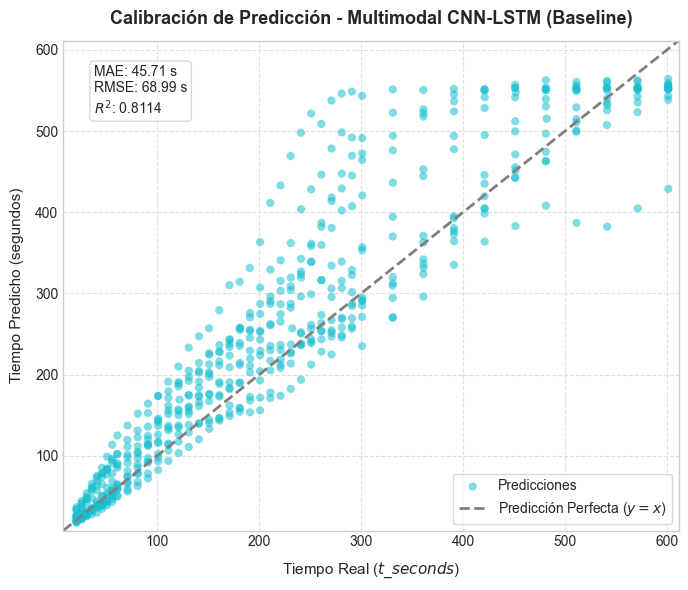

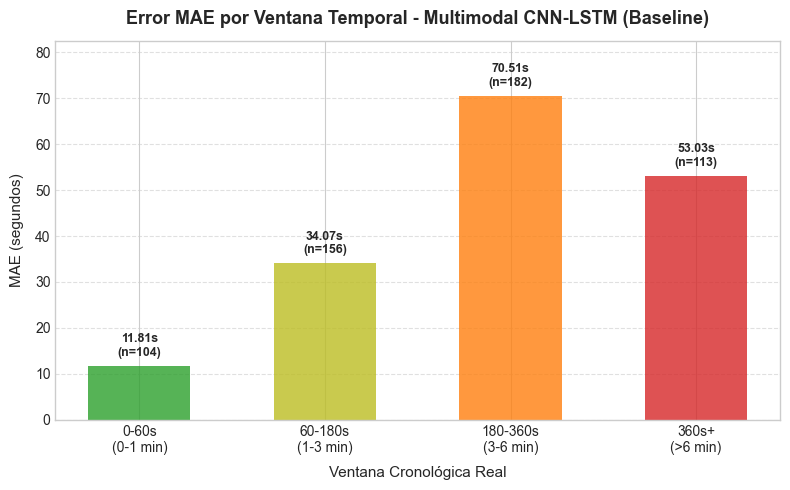

In [7]:
# Colectar predicciones y reales del test set para graficar
model_final.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for x_seq, x_tab, y in test_loader:
        x_seq, x_tab = x_seq.to(dev), x_tab.to(dev)
        p = model_final(x_seq, x_tab)
        all_preds.extend(p.cpu().numpy())
        all_targets.extend(y.numpy())
        
preds_arr = np.array(all_preds)
targets_arr = np.array(all_targets)

# 1. Curva de Calibración
plot_prediction_calibration(targets_arr, preds_arr, model_name="Multimodal CNN-LSTM (Baseline)")

# 2. Gráfico de Error por Ventana de Tiempo
plot_error_by_time_window(targets_arr, preds_arr, model_name="Multimodal CNN-LSTM (Baseline)")